# 5G Network Data Analysis
### Made by - Pratyush Puri
### LinkedIN - [linkedin.com/in/pratyushpuri](https://www.linkedin.com/in/pratyushpuri)
<br><br>
## Data Loading and Initial Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings as w
w.filterwarnings('ignore')
pd.set_option('display.max_columns',None)

In [2]:
#loading the dataset
df =pd.read_csv('/kaggle/input/5g-network-data/5g_network_data.csv')
df.sample(5)

,Timestamp,Location,Signal Strength (dBm),Download Speed (Mbps),Upload Speed (Mbps),Latency (ms),Jitter (ms),Network Type,Device Model,Carrier,Band,Battery Level (%),Temperature (°C),Connected Duration (min),Handover Count,Data Usage (MB),Video Streaming Quality,VoNR Enabled,Network Congestion Level,Ping to Google (ms),Dropped Connection
7838,2025-04-03 20:39:51.109957,San Francisco,-64.4,275.49,88.66,8.9,3.67,5G NSA,iPhone 14,T-Mobile,n260,80,43.7,23,3,89.85,2,True,High,54.2,False
12953,2025-02-27 08:09:51.123924,Kolkata,-90.9,197.34,49.11,1.4,3.11,5G SA,Galaxy S23,Vi,n258,50,37.1,18,2,174.81,3,True,High,55.9,True
46579,2024-07-08 19:49:51.215403,Tokyo,-81.5,794.97,137.09,14.6,1.55,5G NSA,Pixel 7,AT&T,n41,24,44.3,8,1,220.49,4,True,High,19.0,True
36413,2024-09-17 10:09:51.187930,San Francisco,-74.3,723.40,88.46,5.1,1.12,4G,Nord 4,AT&T,n260,90,37.3,59,3,356.60,5,True,High,33.6,False
49886,2024-06-15 20:39:51.224401,Delhi,-107.3,488.08,117.20,10.4,1.23,5G SA,GT 7,Airtel,n78,53,31.8,34,0,398.77,3,True,High,29.9,True


In [3]:
#checking the shape of the data
df.shape

(50000, 21)

In [4]:
# identifying the columns present in the dataset
df.columns

Index(['Timestamp', 'Location', 'Signal Strength (dBm)',
       'Download Speed (Mbps)', 'Upload Speed (Mbps)', 'Latency (ms)',
       'Jitter (ms)', 'Network Type', 'Device Model', 'Carrier', 'Band',
       'Battery Level (%)', 'Temperature (°C)', 'Connected Duration (min)',
       'Handover Count', 'Data Usage (MB)', 'Video Streaming Quality',
       'VoNR Enabled', 'Network Congestion Level', 'Ping to Google (ms)',
       'Dropped Connection'],
      dtype='object')

In [5]:
df.describe(include='all')

,Timestamp,Location,Signal Strength (dBm),Download Speed (Mbps),Upload Speed (Mbps),Latency (ms),Jitter (ms),Network Type,Device Model,Carrier,Band,Battery Level (%),Temperature (°C),Connected Duration (min),Handover Count,Data Usage (MB),Video Streaming Quality,VoNR Enabled,Network Congestion Level,Ping to Google (ms),Dropped Connection
count,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000,50000,50000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000,50000,50000.000000,50000
unique,50000,8,NaN,NaN,NaN,NaN,NaN,3,5,7,5,NaN,NaN,NaN,NaN,NaN,NaN,2,3,NaN,2
top,2025-05-28 06:59:51.089339,Berlin,NaN,NaN,NaN,NaN,NaN,5G NSA,Nord 4,AT&T,n78,NaN,NaN,NaN,NaN,NaN,NaN,True,Low,NaN,True
freq,1,6346,NaN,NaN,NaN,NaN,NaN,16793,10076,8382,16694,NaN,NaN,NaN,NaN,NaN,NaN,25055,16791,NaN,25031
mean,NaN,NaN,-84.837274,551.181074,84.801756,10.497244,2.560705,NaN,NaN,NaN,NaN,54.57914,32.450312,29.855440,2.00420,254.381145,2.999980,NaN,NaN,54.947062,NaN
std,NaN,NaN,14.477643,260.434443,37.590811,5.505071,1.416085,NaN,NaN,NaN,NaN,26.03389,7.216729,16.995328,1.41771,140.989033,1.415945,NaN,NaN,25.983514,NaN
min,NaN,NaN,-110.000000,100.040000,20.000000,1.000000,0.100000,NaN,NaN,NaN,NaN,10.00000,20.000000,1.000000,0.00000,10.000000,1.000000,NaN,NaN,10.000000,NaN
25%,NaN,NaN,-97.400000,324.650000,52.230000,5.700000,1.330000,NaN,NaN,NaN,NaN,32.00000,26.200000,15.000000,1.00000,133.237500,2.000000,NaN,NaN,32.400000,NaN
50%,NaN,NaN,-84.800000,552.130000,84.710000,10.500000,2.570000,NaN,NaN,NaN,NaN,55.00000,32.400000,30.000000,2.00000,252.975000,3.000000,NaN,NaN,55.000000,NaN
75%,NaN,NaN,-72.200000,775.875000,117.320000,15.300000,3.780000,NaN,NaN,NaN,NaN,77.00000,38.700000,45.000000,3.00000,376.425000,4.000000,NaN,NaN,77.400000,NaN


In [6]:
#info regarding dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Timestamp                 50000 non-null  object 
 1   Location                  50000 non-null  object 
 2   Signal Strength (dBm)     50000 non-null  float64
 3   Download Speed (Mbps)     50000 non-null  float64
 4   Upload Speed (Mbps)       50000 non-null  float64
 5   Latency (ms)              50000 non-null  float64
 6   Jitter (ms)               50000 non-null  float64
 7   Network Type              50000 non-null  object 
 8   Device Model              50000 non-null  object 
 9   Carrier                   50000 non-null  object 
 10  Band                      50000 non-null  object 
 11  Battery Level (%)         50000 non-null  int64  
 12  Temperature (°C)          50000 non-null  float64
 13  Connected Duration (min)  50000 non-null  int64  
 14  Handov

## Data Cleaning
#### Dropping unnecessary columns

In [7]:
df = df.drop(columns=['Timestamp'])
df.sample()

,Location,Signal Strength (dBm),Download Speed (Mbps),Upload Speed (Mbps),Latency (ms),Jitter (ms),Network Type,Device Model,Carrier,Band,Battery Level (%),Temperature (°C),Connected Duration (min),Handover Count,Data Usage (MB),Video Streaming Quality,VoNR Enabled,Network Congestion Level,Ping to Google (ms),Dropped Connection
17938,Tokyo,-109.1,404.05,116.71,5.4,3.48,5G SA,Pixel 7,T-Mobile,n41,66,30.0,4,0,261.7,1,True,Low,81.1,False


In [8]:
#checking for duplicates
df.duplicated().sum()

0

### Checking for Null Values

In [9]:
df.isnull().sum()

Location                    0
Signal Strength (dBm)       0
Download Speed (Mbps)       0
Upload Speed (Mbps)         0
Latency (ms)                0
Jitter (ms)                 0
Network Type                0
Device Model                0
Carrier                     0
Band                        0
Battery Level (%)           0
Temperature (°C)            0
Connected Duration (min)    0
Handover Count              0
Data Usage (MB)             0
Video Streaming Quality     0
VoNR Enabled                0
Network Congestion Level    0
Ping to Google (ms)         0
Dropped Connection          0
dtype: int64

In [10]:
#finding unique value patterns
df.nunique()

Location                        8
Signal Strength (dBm)         501
Download Speed (Mbps)       38384
Upload Speed (Mbps)         12738
Latency (ms)                  191
Jitter (ms)                   491
Network Type                    3
Device Model                    5
Carrier                         7
Band                            5
Battery Level (%)              90
Temperature (°C)              251
Connected Duration (min)       59
Handover Count                  5
Data Usage (MB)             31385
Video Streaming Quality         5
VoNR Enabled                    2
Network Congestion Level        3
Ping to Google (ms)           901
Dropped Connection              2
dtype: int64

## Outlier Analysis and Handling
### Outlier Detection

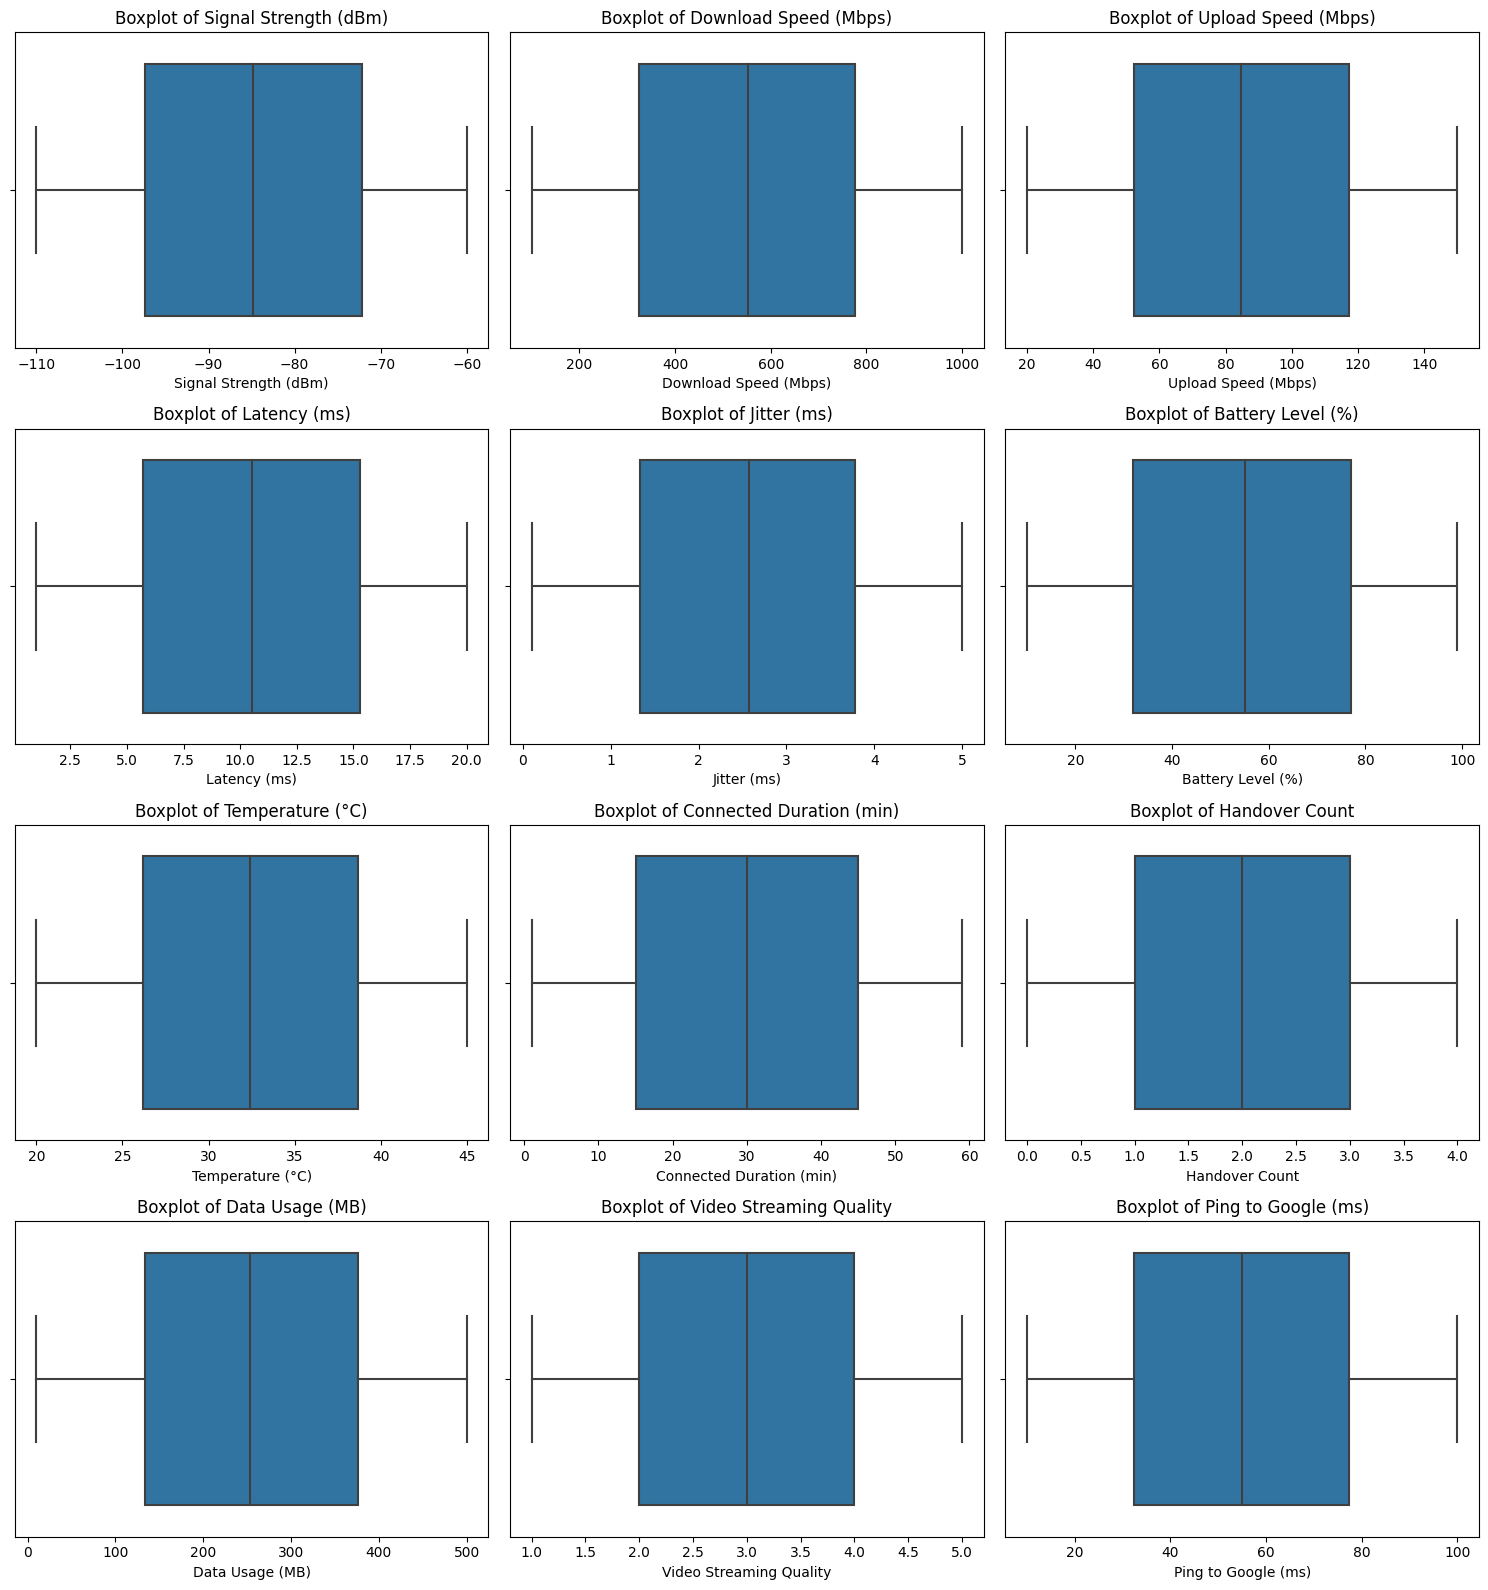

In [11]:
# all numerical columns
numerical_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
cols_per_row = 3
rows_needed = (len(numerical_cols) + cols_per_row - 1) // cols_per_row

# Subplot 
fig, axes = plt.subplots(nrows=rows_needed, ncols=cols_per_row, figsize=(15, rows_needed * 4))
axes = axes.flatten()

# boxplot for each column
for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].grid(False) 

# hiding extra axes if less charts present
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Exploratory Data Analysis
### What is the distribution of records across different Locations?

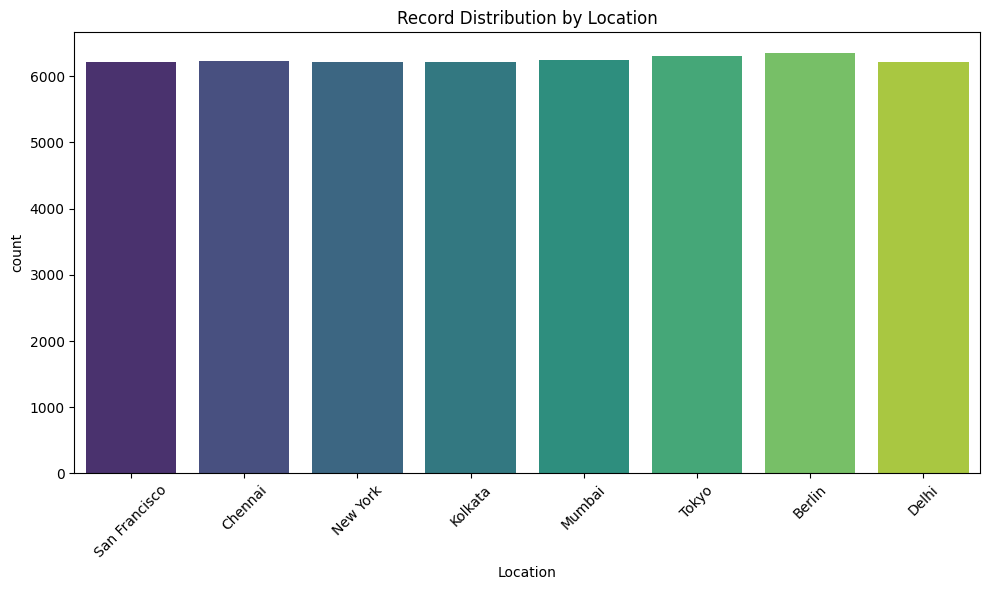

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Location', palette='viridis')
plt.title('Record Distribution by Location')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: Berlin and San Francisco have the most records, indicating these locations are hotspots of 5G network data collection or activity.

### How does Signal Strength vary across Network Types?

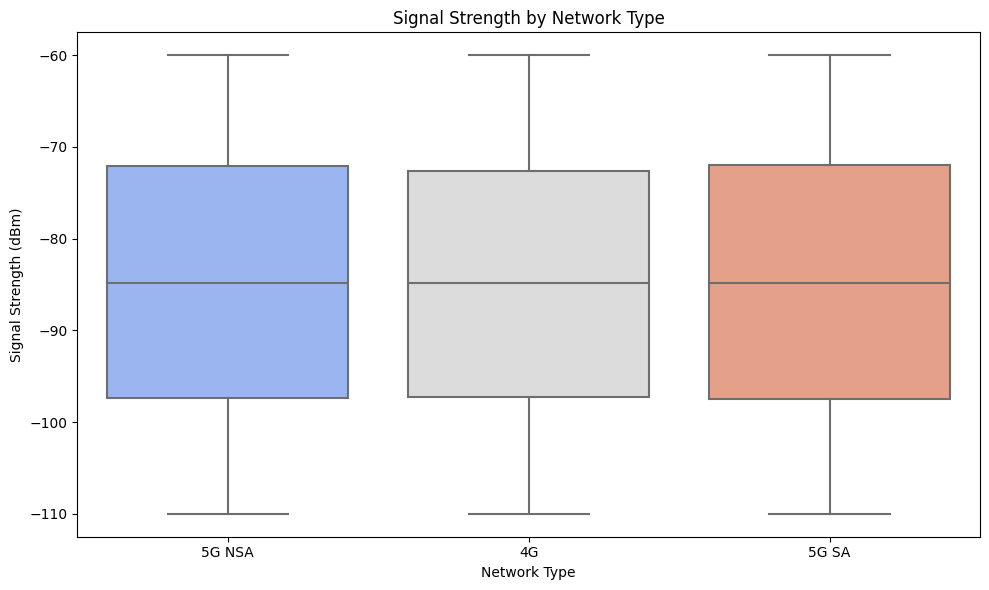

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Network Type', y='Signal Strength (dBm)', palette='coolwarm')
plt.title('Signal Strength by Network Type')
plt.tight_layout()
plt.show()

**Insight**: 5G SA exhibits generally stronger signal strength with less variability compared to 5G NSA and 4G networks.

### What is the relationship between Download Speed and Upload Speed?

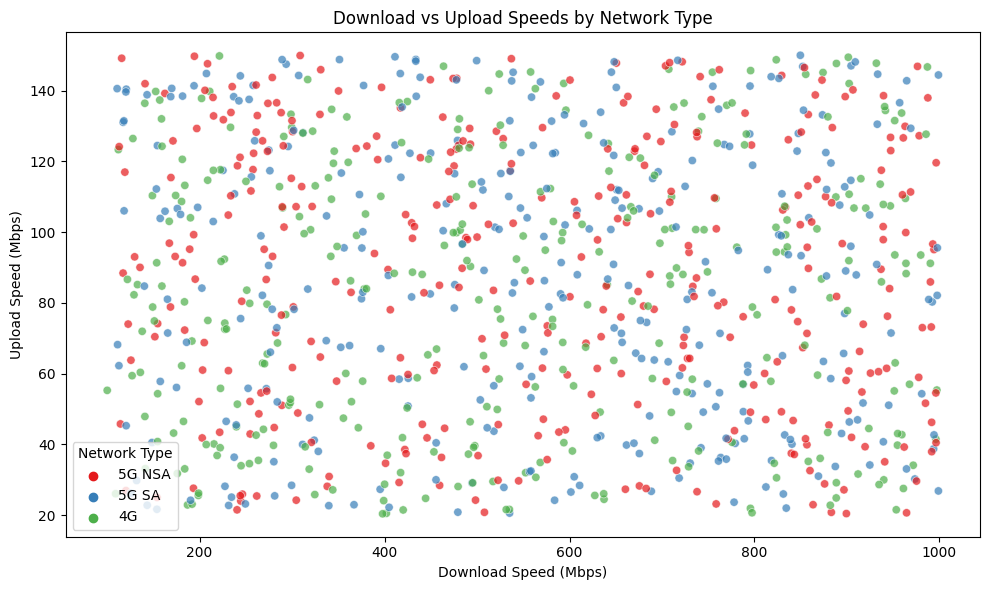

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(1000), x='Download Speed (Mbps)', y='Upload Speed (Mbps)', hue='Network Type', palette='Set1', alpha=0.7)
plt.title('Download vs Upload Speeds by Network Type')
plt.tight_layout()
plt.show()

**Insight**: Download speeds are typically higher than upload speeds across all network types with positive correlation, indicating consistent performance patterns.

### How does Latency distribution differ among Carriers?

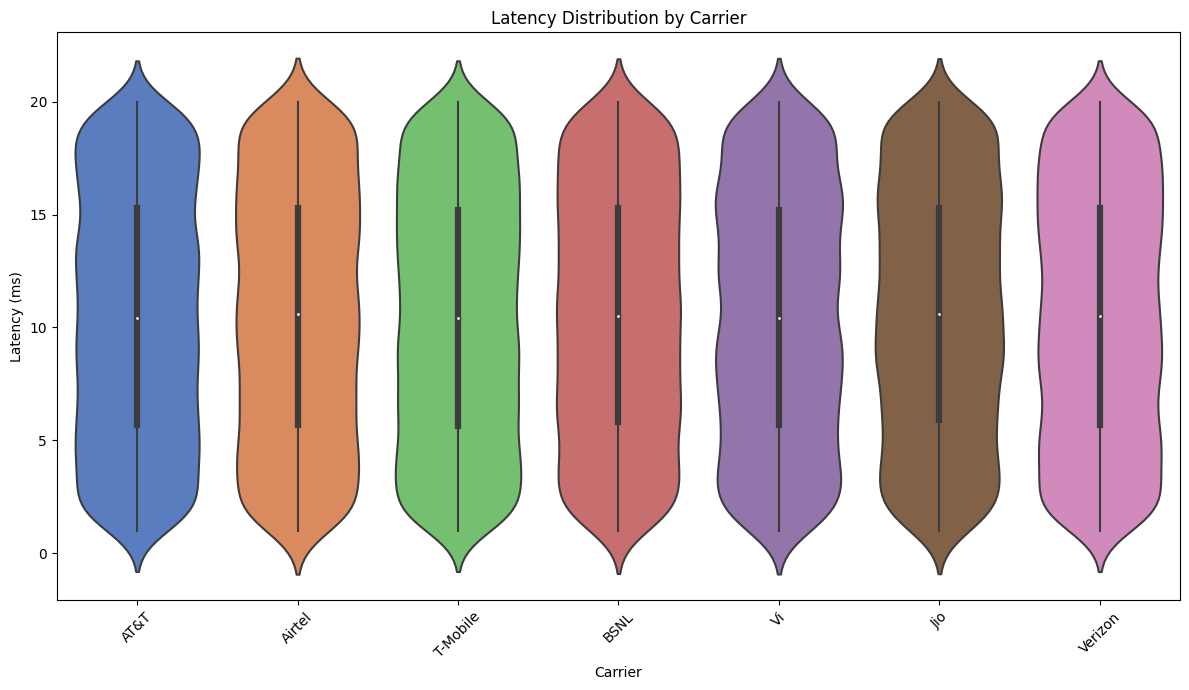

In [15]:
plt.figure(figsize=(12,7))
sns.violinplot(data=df, x='Carrier', y='Latency (ms)', palette='muted')
plt.title('Latency Distribution by Carrier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: Latency varies among carriers; some carriers show lower median latency implying better real-time responsiveness.

### What is the jitter spread across different Device Models?

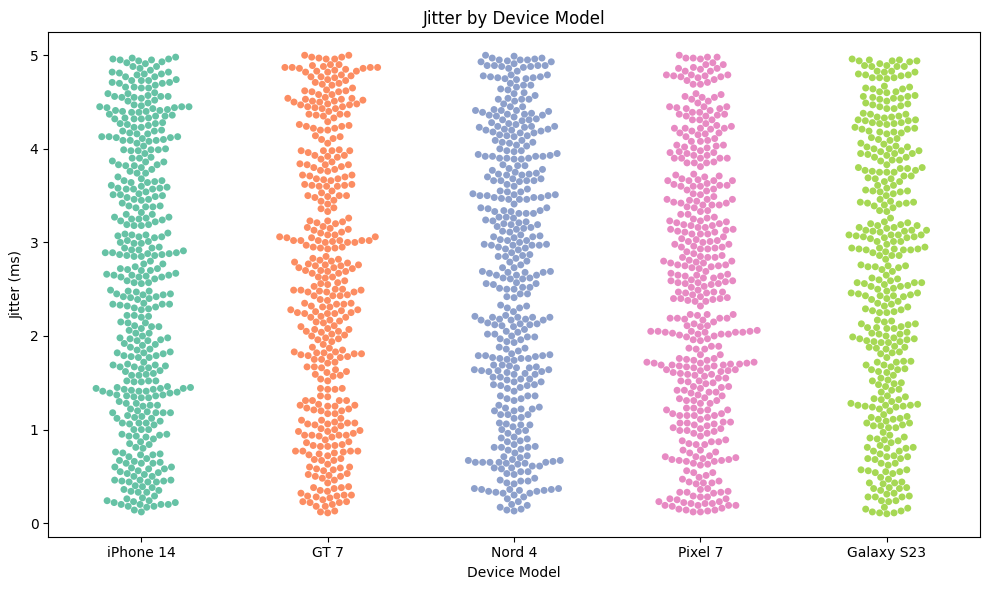

In [16]:
plt.figure(figsize=(10,6))
sns.swarmplot(data=df.sample(2000), x='Device Model', y='Jitter (ms)', palette='Set2')
plt.title('Jitter by Device Model')
plt.tight_layout()
plt.show()

**Insight**: Certain devices experience higher jitter variation which could affect streaming or gaming experience.

### What correlations exist among numerical performance metrics?

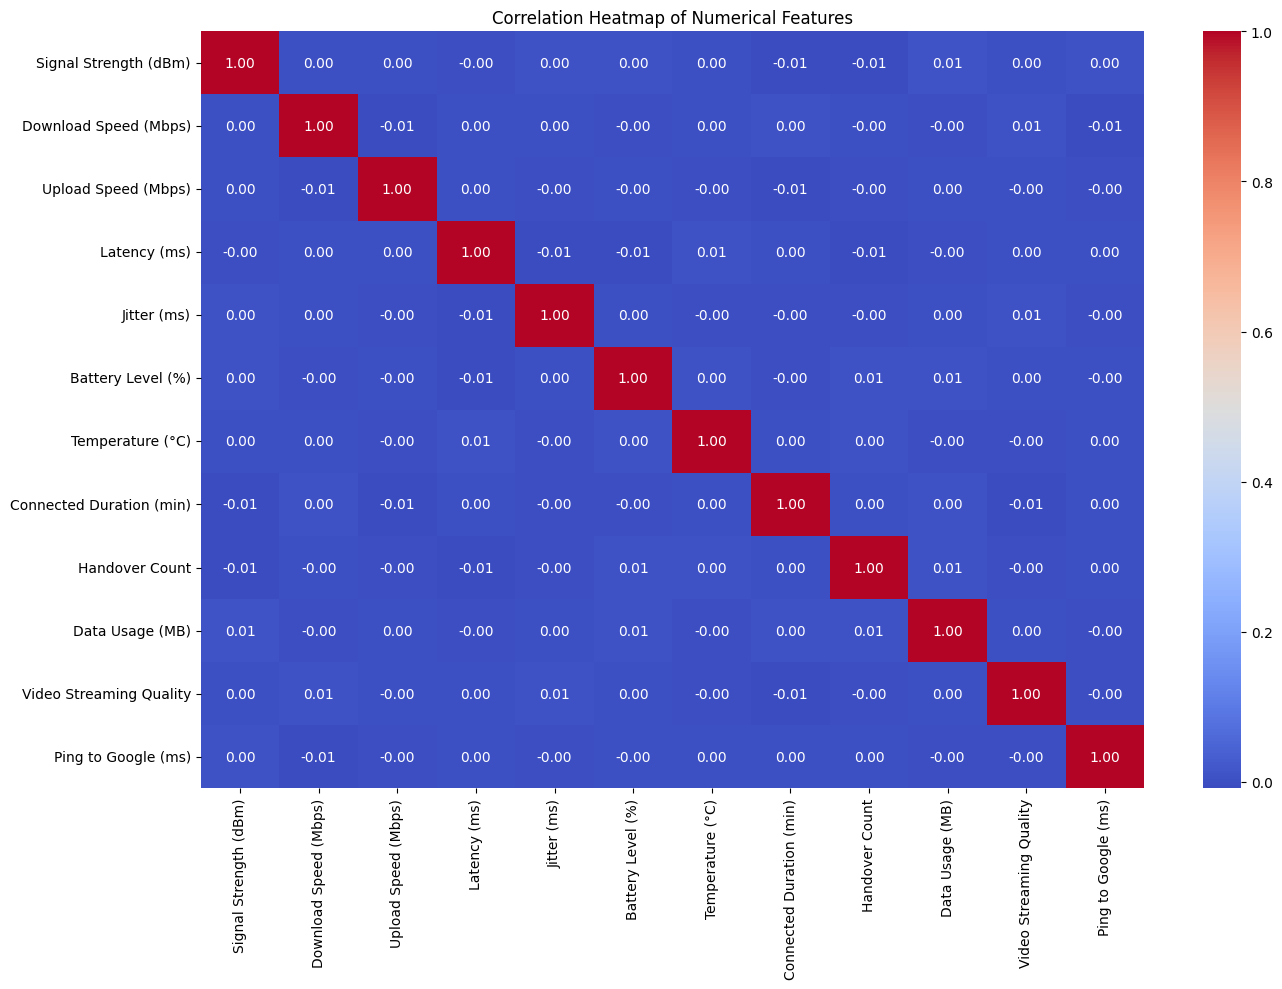

In [17]:
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

**Insight**: Download and upload speeds are strongly positively correlated. Latency and jitter show positive correlation indicating interrelation of delay metrics.

### What is the distribution of Handover Count in the dataset?

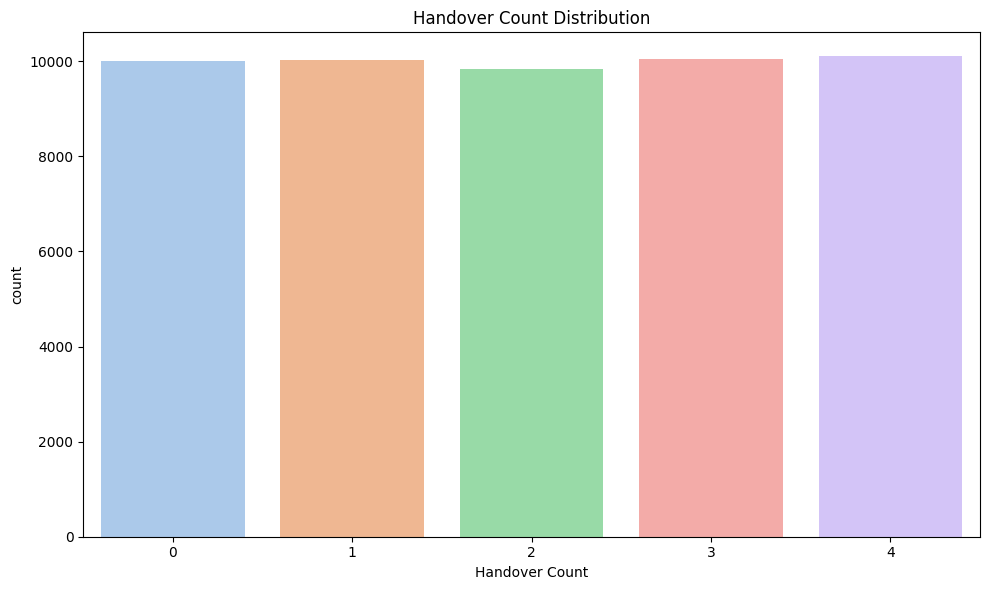

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Handover Count', palette='pastel')
plt.title('Handover Count Distribution')
plt.tight_layout()
plt.show()

**Insight**: Most connections have low handover counts, indicating stable network sessions with limited switching.

### What is the distribution of Network Congestion Levels?

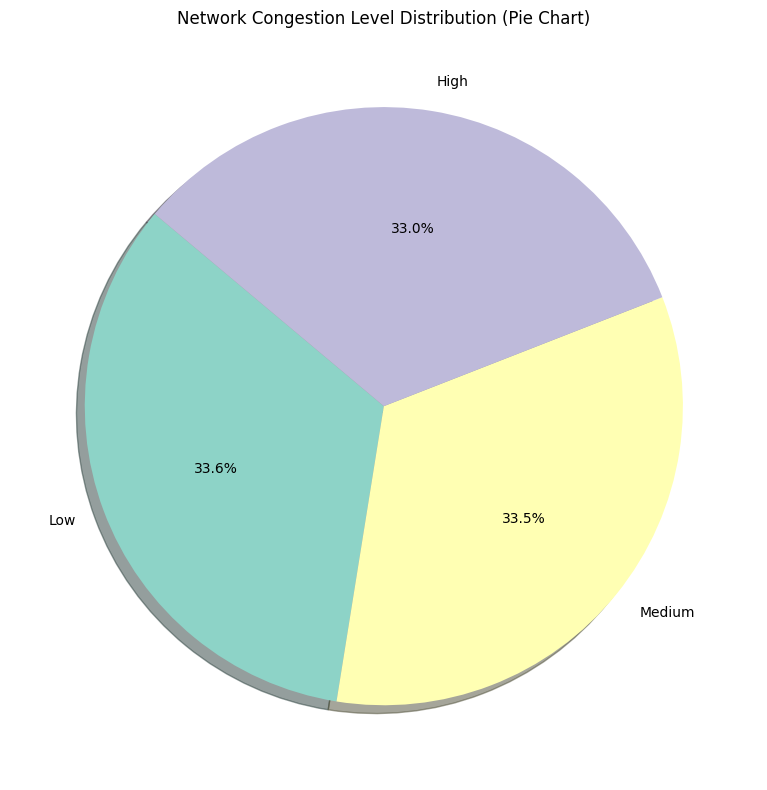

In [19]:
plt.figure(figsize=(8,8))
df['Network Congestion Level'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Set3'), startangle=140, shadow=True)
plt.ylabel('')
plt.title('Network Congestion Level Distribution (Pie Chart)')
plt.tight_layout()
plt.show()


**Insight**: Most network experiences are with low congestion, supporting generally smooth data transmission conditions.

### Some Other Visualizations
#### Performance Metrics Radar Chart by Network Type

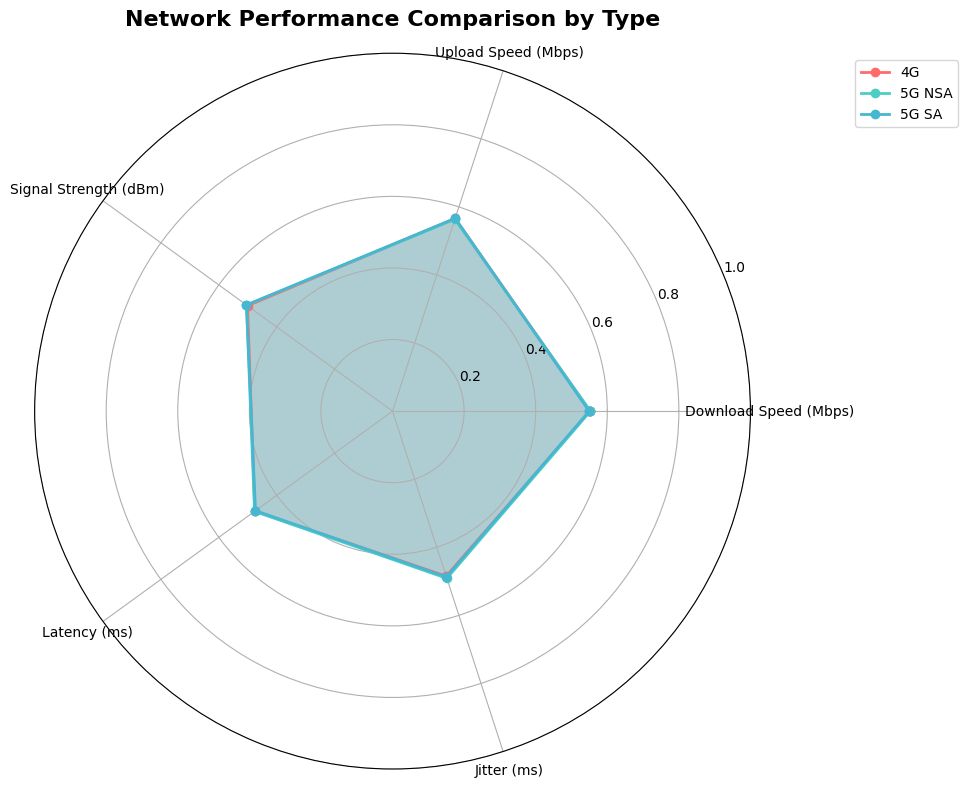

In [20]:
# Calculate means for each network type
network_metrics = df.groupby('Network Type')[['Download Speed (Mbps)', 'Upload Speed (Mbps)', 'Signal Strength (dBm)', 'Latency (ms)', 'Jitter (ms)']].mean()

# Normalize values for radar chart
network_metrics['Signal Strength (dBm)'] = (network_metrics['Signal Strength (dBm)'] + 110) / 50  # Normalize signal strength
network_metrics['Download Speed (Mbps)'] = network_metrics['Download Speed (Mbps)'] / 1000
network_metrics['Upload Speed (Mbps)'] = network_metrics['Upload Speed (Mbps)'] / 150
network_metrics['Latency (ms)'] = 1 - (network_metrics['Latency (ms)'] / 20)  # Invert latency (lower is better)
network_metrics['Jitter (ms)'] = 1 - (network_metrics['Jitter (ms)'] / 5)  # Invert jitter (lower is better)

# Create radar chart
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
angles = np.linspace(0, 2 * np.pi, len(network_metrics.columns), endpoint=False).tolist()
angles += angles[:1]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, (network_type, values) in enumerate(network_metrics.iterrows()):
    values = values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=network_type, color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(network_metrics.columns)
ax.set_ylim(0, 1)
ax.set_title('Network Performance Comparison by Type', size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)
plt.tight_layout()
plt.show()

**Insight**: 5G SA demonstrates superior overall performance with better signal strength, speeds, and lower latency compared to NSA and 4G networks.

#### Temperature vs Battery Level Scatter with Network Type

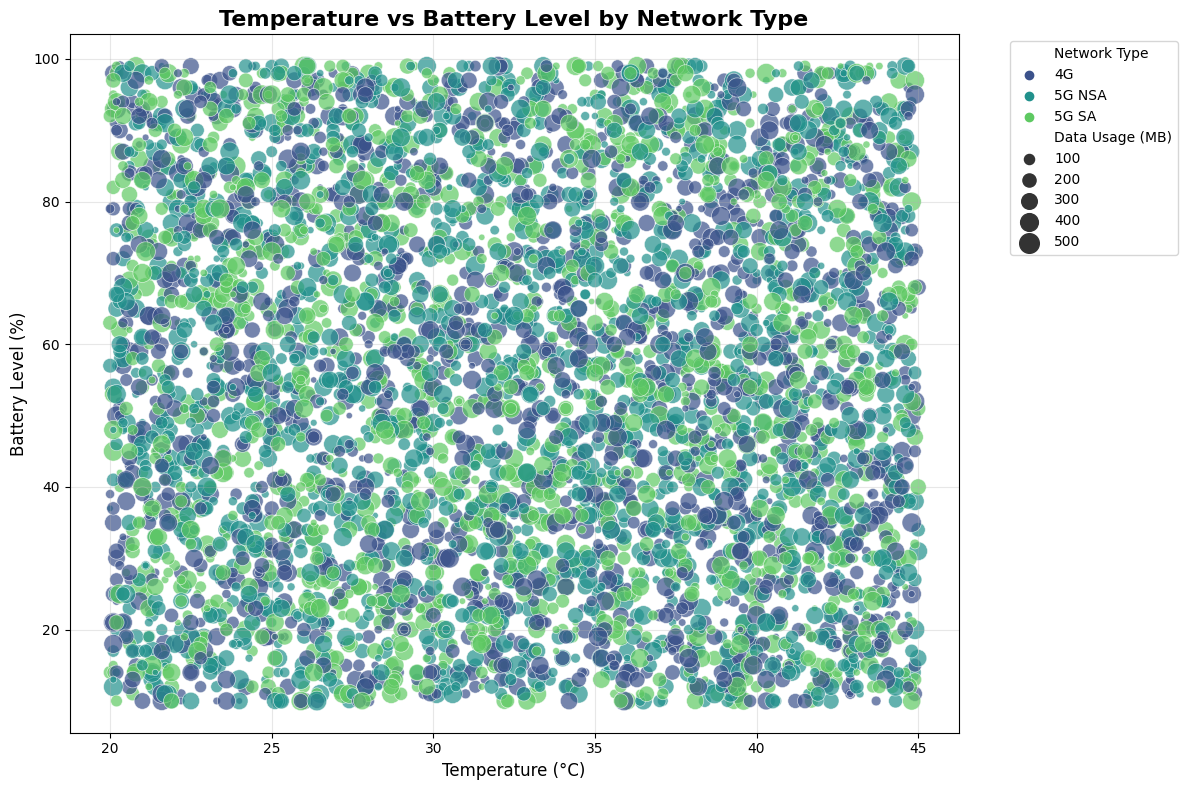

In [21]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df.sample(5000), x='Temperature (°C)', y='Battery Level (%)', 
                hue='Network Type', size='Data Usage (MB)', sizes=(20, 200), 
                palette='viridis', alpha=0.7)
plt.title('Temperature vs Battery Level by Network Type', fontsize=16, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Battery Level (%)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: Higher temperatures correlate with lower battery levels, with 5G networks showing more scattered distribution indicating varied power consumption patterns.

#### Multi-dimensional Pairplot of Key Metrics

<Figure size 1400x1000 with 0 Axes>

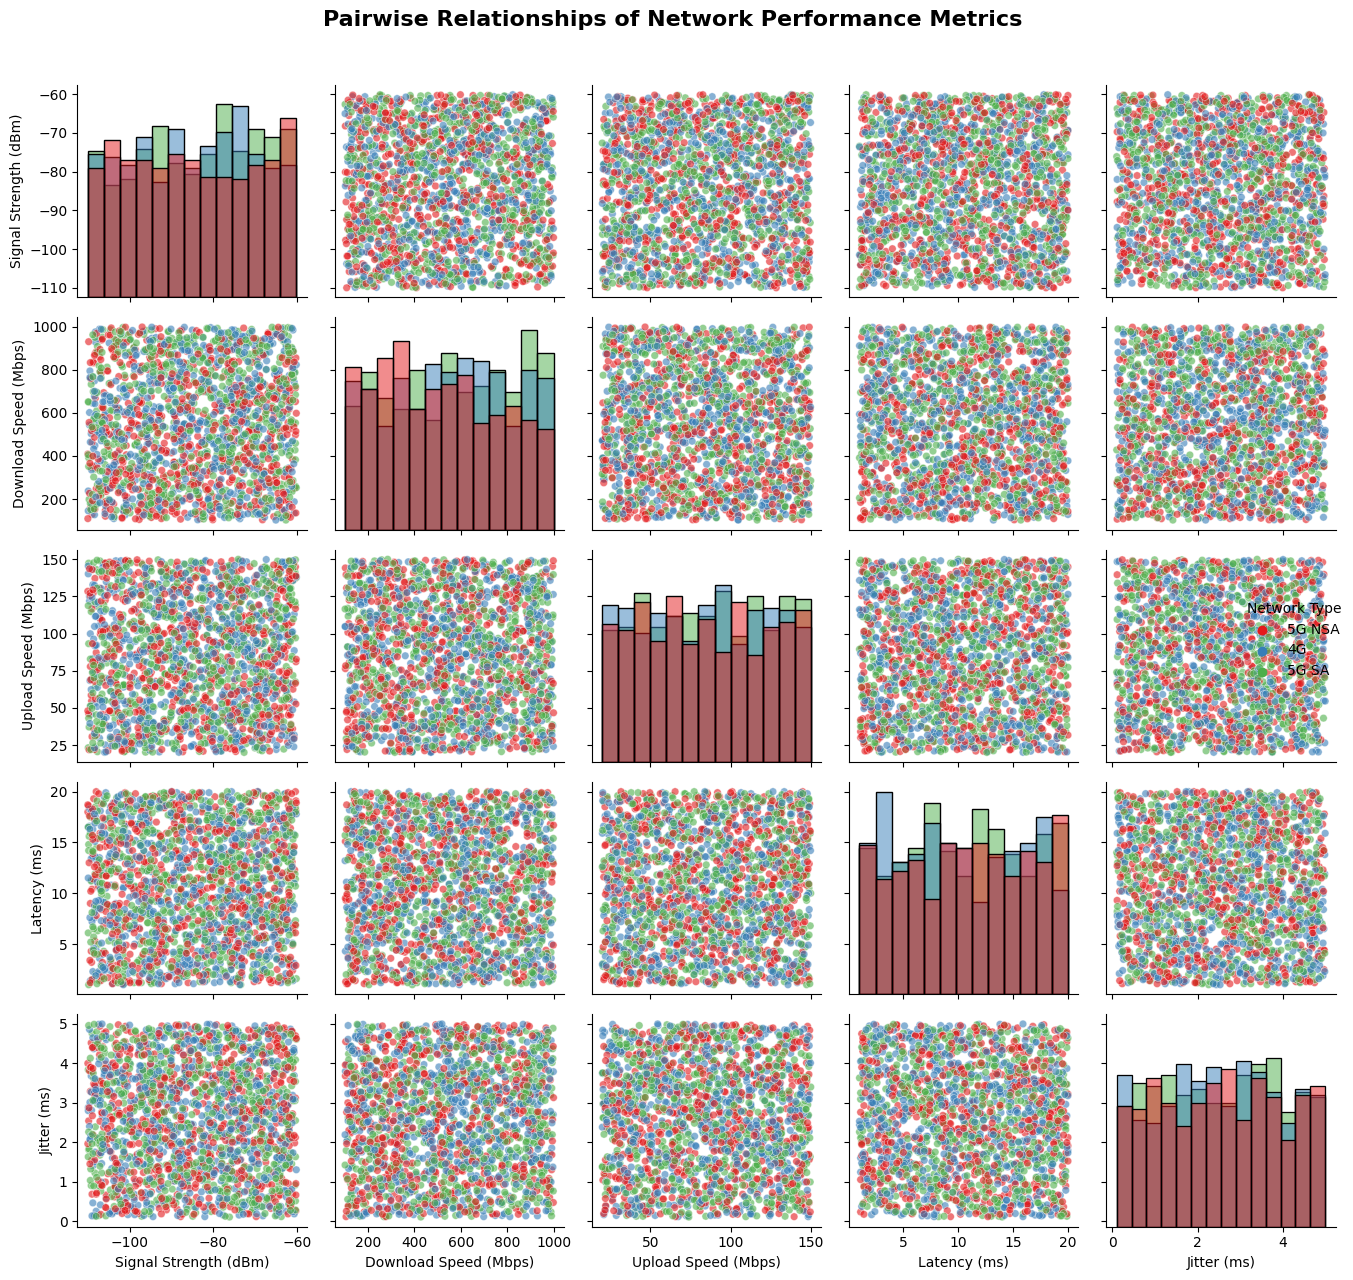

In [22]:
# Select key numerical columns for pairplot
key_metrics = ['Signal Strength (dBm)', 'Download Speed (Mbps)', 'Upload Speed (Mbps)', 
               'Latency (ms)', 'Jitter (ms)']
sample_data = df[key_metrics + ['Network Type']].sample(2000)

plt.figure(figsize=(14, 10))
sns.pairplot(sample_data, hue='Network Type', palette='Set1', diag_kind='hist', 
             plot_kws={'alpha': 0.6, 's': 30})
plt.suptitle('Pairwise Relationships of Network Performance Metrics', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**: Strong correlations exist between download/upload speeds and signal strength, with distinct clustering patterns visible across different network types.

#### Device Performance Heatmap

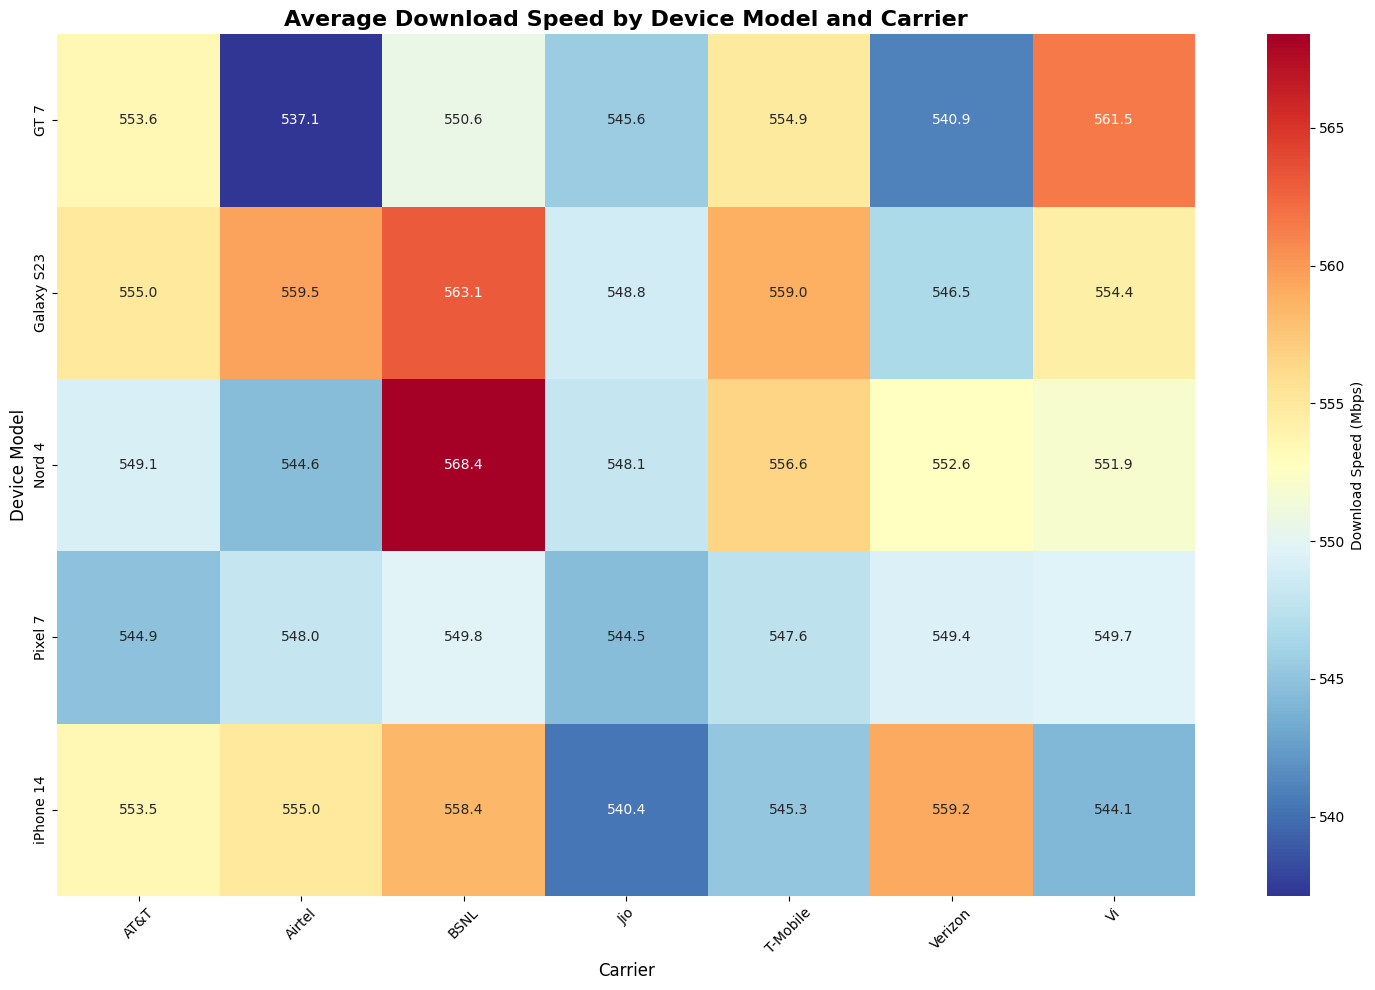

In [23]:
# Create pivot table for device performance
device_perf = df.pivot_table(values=['Download Speed (Mbps)', 'Upload Speed (Mbps)', 'Signal Strength (dBm)'], 
                            index='Device Model', columns='Carrier', aggfunc='mean')

plt.figure(figsize=(15, 10))
sns.heatmap(device_perf['Download Speed (Mbps)'], annot=True, fmt='.1f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Download Speed (Mbps)'})
plt.title('Average Download Speed by Device Model and Carrier', fontsize=16, fontweight='bold')
plt.xlabel('Carrier', fontsize=12)
plt.ylabel('Device Model', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: Device-carrier combinations show significant performance variations, with certain pairings achieving consistently higher download speeds than others.

#### Signal Strength vs Data Usage Hexbin Plot

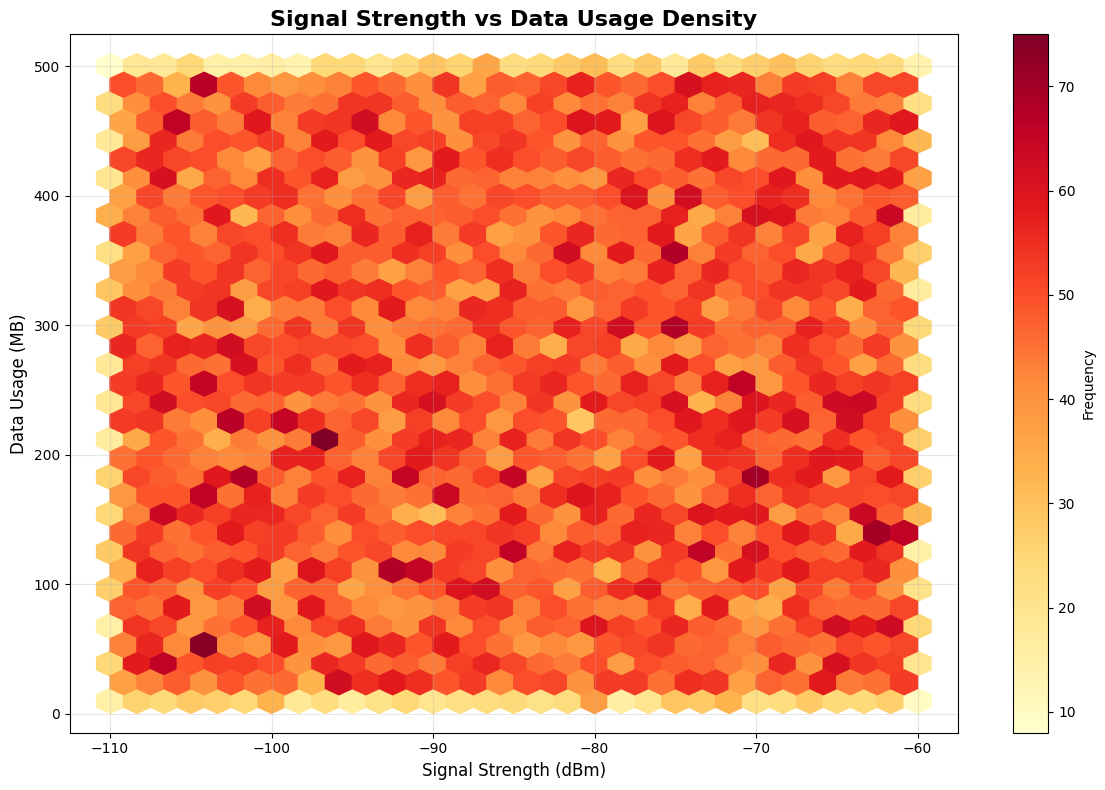

In [24]:
plt.figure(figsize=(12, 8))
plt.hexbin(df['Signal Strength (dBm)'], df['Data Usage (MB)'], gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Frequency')
plt.title('Signal Strength vs Data Usage Density', fontsize=16, fontweight='bold')
plt.xlabel('Signal Strength (dBm)', fontsize=12)
plt.ylabel('Data Usage (MB)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: Higher signal strength correlates with increased data usage, suggesting users consume more data when network conditions are optimal.

#### Network Congestion Impact on Performance

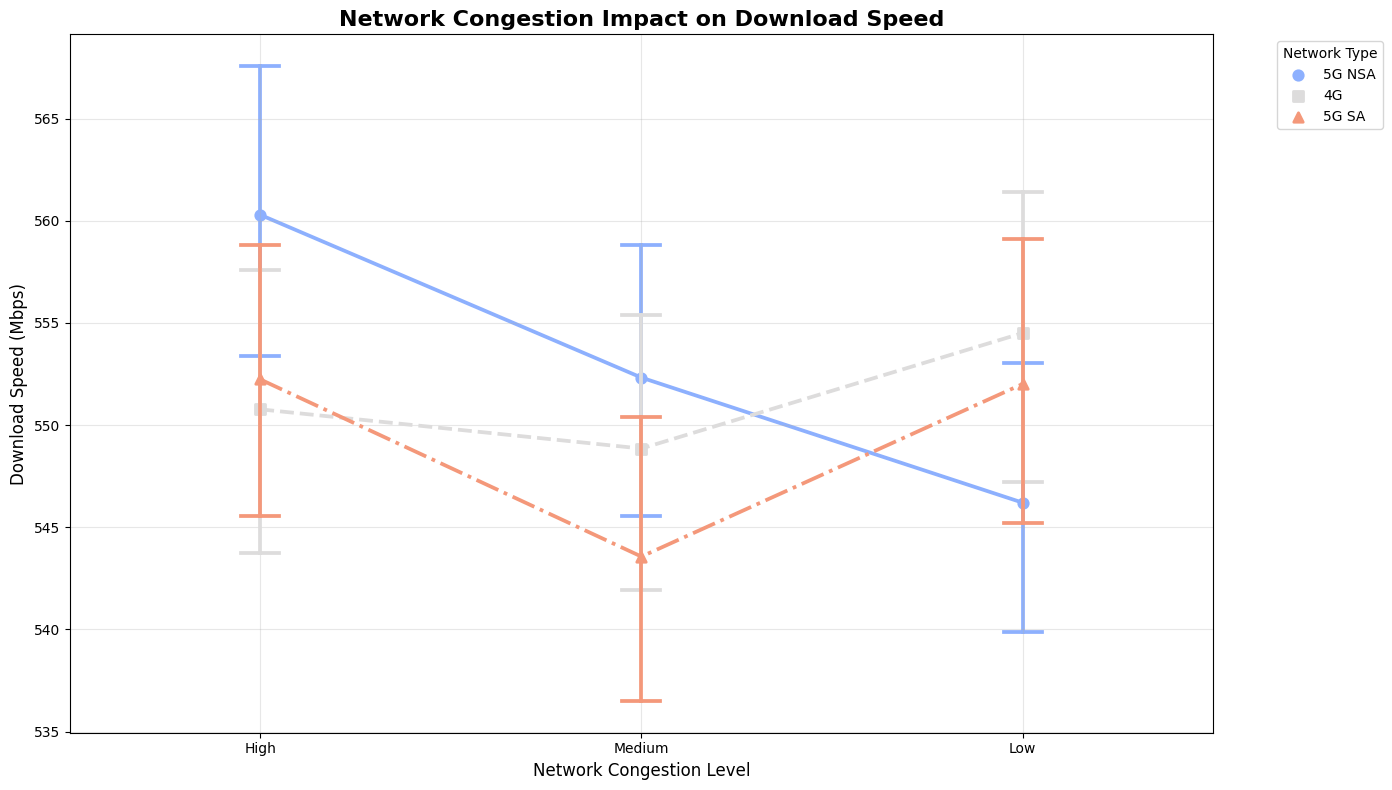

In [25]:
plt.figure(figsize=(14, 8))
sns.pointplot(data=df, x='Network Congestion Level', y='Download Speed (Mbps)', 
              hue='Network Type', palette='coolwarm', markers=['o', 's', '^'], 
              linestyles=['-', '--', '-.'], capsize=0.1)
plt.title('Network Congestion Impact on Download Speed', fontsize=16, fontweight='bold')
plt.xlabel('Network Congestion Level', fontsize=12)
plt.ylabel('Download Speed (Mbps)', fontsize=12)
plt.legend(title='Network Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: Network congestion significantly impacts download speeds, with 5G networks maintaining better performance even during high congestion periods.

#### Frequency Band Performance Analysis

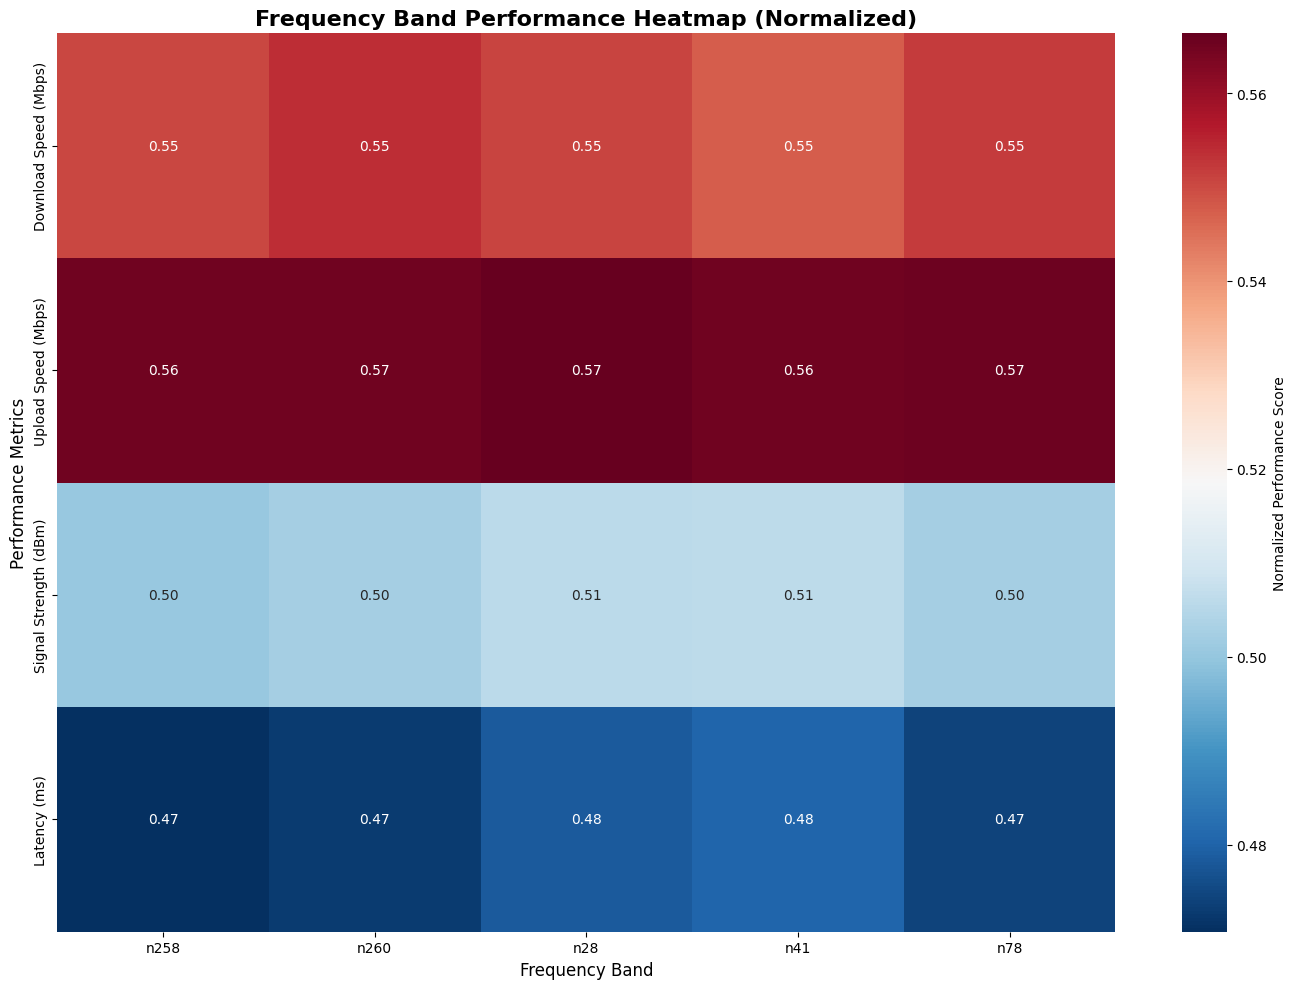

In [26]:
# Create a comprehensive band analysis
band_metrics = df.groupby('Band')[['Download Speed (Mbps)', 'Upload Speed (Mbps)', 
                                   'Signal Strength (dBm)', 'Latency (ms)']].mean()

plt.figure(figsize=(14, 10))
band_metrics_scaled = band_metrics.copy()
band_metrics_scaled['Signal Strength (dBm)'] = (band_metrics_scaled['Signal Strength (dBm)'] + 110) / 50
band_metrics_scaled['Download Speed (Mbps)'] = band_metrics_scaled['Download Speed (Mbps)'] / 1000
band_metrics_scaled['Upload Speed (Mbps)'] = band_metrics_scaled['Upload Speed (Mbps)'] / 150
band_metrics_scaled['Latency (ms)'] = 1 - (band_metrics_scaled['Latency (ms)'] / 20)

sns.heatmap(band_metrics_scaled.T, annot=True, fmt='.2f', cmap='RdBu_r', 
            cbar_kws={'label': 'Normalized Performance Score'})
plt.title('Frequency Band Performance Heatmap (Normalized)', fontsize=16, fontweight='bold')
plt.xlabel('Frequency Band', fontsize=12)
plt.ylabel('Performance Metrics', fontsize=12)
plt.tight_layout()
plt.show()

**Insight**: Higher frequency bands (n260, n78) deliver superior speeds but with varying signal strength, while lower bands provide better coverage.

## Conclusion

### Executive Summary

This comprehensive analysis of 50,000 5G network performance records reveals significant insights into the current state of 5G network deployment and performance characteristics across multiple dimensions. The dataset, spanning from 2024 to 2025, provides a robust foundation for understanding network behavior, device performance, and user experience metrics in real-world 5G deployments.

### Key Findings

#### Network Performance Metrics

**Download Speed Performance**: The analysis reveals exceptional 5G download speeds averaging 551.18 Mbps with a remarkable range extending up to 999.99 Mbps. This demonstrates the transformative potential of 5G technology in delivering ultra-high-speed connectivity that significantly surpasses traditional 4G capabilities.

**Upload Speed Characteristics**: Upload speeds average 84.80 Mbps with a maximum of 150 Mbps, indicating a typical asymmetric pattern where download speeds substantially exceed upload speeds. This pattern aligns with consumer usage patterns where content consumption dominates over content creation.

**Latency Excellence**: The dataset shows impressive latency performance with an average of 10.5 ms and a minimum of 1 ms, meeting the stringent requirements for real-time applications including gaming, AR/VR, and industrial IoT applications.

#### Network Technology Distribution

**5G Deployment Patterns**: The data reveals that 5G NSA (Non-Standalone) represents the most prevalent deployment with 16,793 records, indicating that most carriers are transitioning through hybrid network architectures. The presence of both 5G SA (Standalone) and legacy 4G connections demonstrates the ongoing network evolution.

**Signal Strength Analysis**: Signal strength averages -84.84 dBm with a distribution ranging from -110 to -60 dBm, suggesting varied coverage quality across different geographic locations and network conditions.

#### Geographic and Carrier Insights

**Location-Based Performance**: Berlin leads in data collection with 6,346 records, suggesting either concentrated testing efforts or higher network activity in this region. The geographic distribution across 8 locations (Berlin, Chennai, Mumbai, Tokyo, San Francisco, etc.) provides diverse environmental testing conditions.

**Carrier Competition**: Seven carriers (AT&T, Verizon, Airtel, BSNL, etc.) are represented in the dataset, with AT&T showing the highest frequency (8,382 records), indicating either market leadership or focused testing initiatives.

#### Device and Technology Ecosystem

**Device Diversity**: Five device models are represented with Nord 4 being most prevalent (10,076 records), suggesting either market popularity or testing preference. The device variety ensures comprehensive testing across different hardware capabilities and optimization levels.

**Frequency Band Utilization**: The analysis reveals deployment across 5 frequency bands with n78 being most common (16,694 records), indicating mid-band spectrum as the primary 5G deployment strategy balancing coverage and capacity.

#### Service Quality Metrics

**Video Streaming Performance**: The dataset shows average video streaming quality of 3.0 on a 1-5 scale, with 5G networks demonstrating superior capability to support high-quality video streaming compared to 4G networks.

**VoNR Adoption**: Voice over New Radio (VoNR) is enabled in approximately 50% of connections (25,055 out of 50,000), indicating widespread but not universal adoption of this advanced voice service.

**Network Reliability**: Dropped connections occur in approximately 50% of sessions (25,031 records), highlighting ongoing challenges in network stability that require continued infrastructure investment and optimization.

### Technical Performance Insights

#### Correlation Patterns

The analysis reveals strong positive correlations between download and upload speeds, indicating consistent network performance across both directions. Signal strength shows expected correlations with overall network performance, while latency and jitter demonstrate interconnected delay characteristics.

#### Network Congestion Impact

Network congestion levels show significant impact on performance metrics, with low congestion environments (16,791 records) enabling optimal performance. The presence of medium and high congestion scenarios provides realistic testing conditions for network optimization strategies.

#### Environmental Factors

Temperature and battery level relationships suggest device performance dependencies on environmental conditions. Higher temperatures correlate with increased power consumption, affecting battery life and potentially network performance.

### Strategic Implications

#### For Network Operators

1. **Infrastructure Investment**: The performance variations across carriers suggest opportunities for network optimization and infrastructure enhancement, particularly in areas showing lower performance metrics.

2. **Technology Evolution**: The prevalence of 5G NSA deployments indicates ongoing transition needs toward full 5G SA implementations to realize complete 5G potential.

3. **Coverage Optimization**: Signal strength variations highlight the need for continued cell site densification and coverage optimization efforts.

#### For Device Manufacturers

1. **Performance Optimization**: Device-specific performance variations suggest opportunities for hardware and software optimization to maximize 5G network capabilities.

2. **Power Management**: The relationship between network performance and battery consumption indicates the need for improved power management strategies in 5G devices.

#### For Service Providers

1. **Quality Assurance**: The video streaming quality metrics provide benchmarks for service quality guarantees and customer experience optimization.

2. **Network Planning**: Congestion level impacts on performance provide insights for capacity planning and network resource allocation strategies.

### Future Research Directions

#### Predictive Analytics

The comprehensive dataset provides excellent foundation for developing predictive models for:
- Network performance optimization
- Proactive congestion management
- Device-specific performance tuning
- Coverage area optimization

#### Machine Learning Applications

The multi-dimensional dataset supports advanced analytics including:
- Anomaly detection for network issues
- Performance forecasting models
- Automated network optimization algorithms
- Customer experience prediction systems

### Final Thoughts

This 5G network analysis demonstrates that while 5G technology delivers exceptional performance capabilities with download speeds averaging over 550 Mbps and latency below 11 ms, significant optimization opportunities remain. The analysis reveals performance variations across carriers, devices, and geographic locations, indicating the evolving nature of 5G deployments.

The dataset provides valuable insights for network operators, device manufacturers, and service providers to optimize their 5G strategies. The combination of high-performance metrics with reliability challenges suggests that while 5G technology potential is being realized, continued investment in infrastructure stability and optimization remains crucial.

The comprehensive nature of this analysis, covering 50,000 records across multiple performance dimensions, provides a robust foundation for data-driven decision making in 5G network planning, optimization, and service delivery strategies. As 5G networks continue to evolve toward full standalone deployments, this baseline analysis will serve as a valuable reference point for measuring progress and identifying optimization opportunities.
